In [29]:
from config import client
import pandas as pd
from graph import plot_bar_graph, plot_line_graph, plot_pie_chart,plot_box_plot,plot_scatter_plot,plot_heatmap

In [30]:
invoice_query = """
SELECT * FROM zoho_books_analytics.invoices
"""

result = client.query(invoice_query)

invoice_df = pd.DataFrame(result.result_rows, columns=[col for col in result.column_names])

In [31]:
invoice_df.head()

,invoice_id,invoice_date,invoice_number,status,invoice_status,due_date,customer_id,discount_,sub_total_bcy,shipping_charge_bcy,...,estimate_id,modified_by,recurring_invoice_id,transaction_posting_date,tax_authority_id,tax_exemption_id,tax_id,subscription_id,pricelist_id,shipping_charge_tax_id
0,1410873000000328306,19 Dec 2017,AZ-2448,Closed,Closed,19 Dec 2017,1410873000000184329,0.00%,"USD 8,352.00",USD 0.00,...,,1410873000000860021,,19 Dec 2017,,,,,1410873000000011001,
1,1410873000000328322,27 Dec 2017,AZ-2368,Closed,Closed,27 Dec 2017,1410873000000184329,0.00%,"USD 22,404.00",USD 0.00,...,,1410873000000860021,,27 Dec 2017,,,,,1410873000000011001,
2,1410873000000328336,09 Apr 2018,AZ-1741/101735,Closed,Closed,19 Apr 2018,1410873000000184929,0.00%,"USD 8,640.00",USD 0.00,...,,1410873000000860021,,09 Apr 2018,,,,,1410873000000011001,
3,1410873000000328350,13 Apr 2018,AZ-2612,Closed,Closed,13 Apr 2018,1410873000000185013,0.00%,"USD 16,007.00",USD 0.00,...,,1410873000000065001,,13 Apr 2018,,,,,1410873000000011001,
4,1410873000000328364,20 Apr 2018,AZ-2614,Closed,Closed,20 Apr 2018,1410873000000185013,0.00%,"USD 29,916.00",USD 0.00,...,,1410873000000065001,,20 Apr 2018,,,,,1410873000000011001,


In [32]:
invoice_df.columns

Index(['invoice_id', 'invoice_date', 'invoice_number', 'status',
       'invoice_status', 'due_date', 'customer_id', 'discount_',
       'sub_total_bcy', 'shipping_charge_bcy', 'adjustment_bcy', 'total_bcy',
       'created_time', 'discount_amount', 'age_in_days', 'age_tier',
       'crm_potential_id', 'purchase_order', 'currency_code',
       'sales_person_id', 'exchange_rate', 'discount_type',
       'is_discount_before_tax', 'is_inclusive_tax', 'crm_reference_id',
       'source', 'sub_total_fcy', 'total_fcy', 'balance_bcy', 'balance_fcy',
       'shipping_charge_fcy', 'adjustment_fcy', 'payment_terms',
       'payment_terms_label', 'notes', 'terms__conditions',
       'write_off_amount_fcy', 'write_off_amount_bcy', 'expected_payment_date',
       'last_payment_date', 'last_modified_time', 'coo', 'port_of_loading',
       'country_of_destination', 'final_destination', 'warehouse',
       'customer_po', 'pickup_date', 'manifest_notes', 'discount_amount_bcy',
       'discount_amount_f

In [33]:
columns_to_drop = ['sub_total_fcy', 'total_fcy','shipping_charge_fcy', 'adjustment_fcy', 'payment_terms', 'payment_terms_label',
                    'warehouse', 'discount_amount_fcy', 'container', 'write_off_date', 'invoice_transaction_type',
                    'shipping_charge_tax_amount_fcy',''
                    'write_off_amount_fcy', 'write_off_amount_bcy', 'expected_payment_date', 'port_of_loading',
                    'balance_bcy', 'balance_fcy','source','is_inclusive_tax','is_discount_before_tax',
                    'shipping_charge_bcy','invoice_id','status','customer_id','crm_potential_id',
                    'currency_code','sales_person_id','exchange_rate','crm_reference_id','terms__conditions',
                    'notes','manifest_notes','address_id','write_off_description','internal_notes','estimate_id',
                    'recurring_invoice_id','tax_authority_id','tax_exemption_id','tax_id','subscription_id',
                    'pricelist_id','shipping_charge_tax_id']
invoice_df = invoice_df.drop(columns=columns_to_drop)

In [34]:
# need to check this again -> age_in_days
# invoice_df['transaction_posting_date'].value_counts(sort=True, ascending=True)

In [35]:
invoice_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45344 entries, 0 to 45343
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype                  
---  ------                    --------------  -----                  
 0   invoice_date              45344 non-null  object                 
 1   invoice_number            45344 non-null  object                 
 2   invoice_status            45344 non-null  object                 
 3   due_date                  45344 non-null  object                 
 4   discount_                 45344 non-null  object                 
 5   sub_total_bcy             45344 non-null  object                 
 6   adjustment_bcy            45344 non-null  object                 
 7   total_bcy                 45344 non-null  object                 
 8   created_time              45344 non-null  datetime64[ns, Etc/UTC]
 9   discount_amount           45344 non-null  object                 
 10  age_in_days               45344 no

In [36]:
# Count empty strings in each column
empty_counts = (invoice_df == '').sum()
empty_counts

invoice_date                    0
invoice_number                  0
invoice_status                  0
due_date                        0
discount_                       0
sub_total_bcy                   0
adjustment_bcy                  0
total_bcy                       0
created_time                    0
discount_amount                 0
age_in_days                     0
age_tier                        0
purchase_order                766
discount_type                   0
last_payment_date            2369
last_modified_time              0
coo                         16657
country_of_destination      27768
final_destination            5452
customer_po                  1319
pickup_date                 14441
discount_amount_bcy             0
az                          33018
invoice_date_range              0
created_by                      0
modified_by                     1
transaction_posting_date        0
dtype: int64

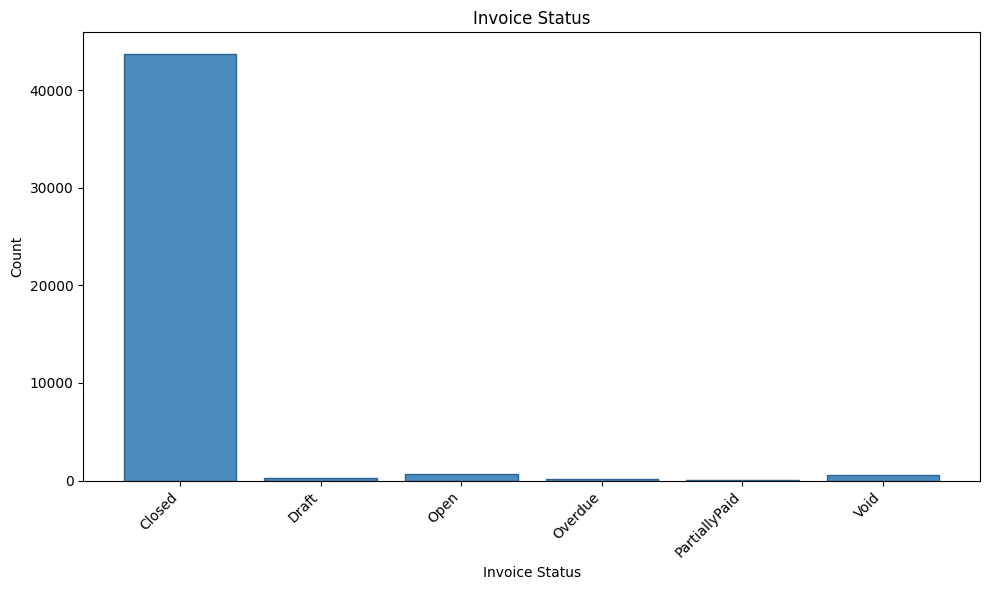

In [37]:
plot_bar_graph(invoice_df['invoice_status'], title="Invoice Status", x_label="Invoice Status", y_label="Count")

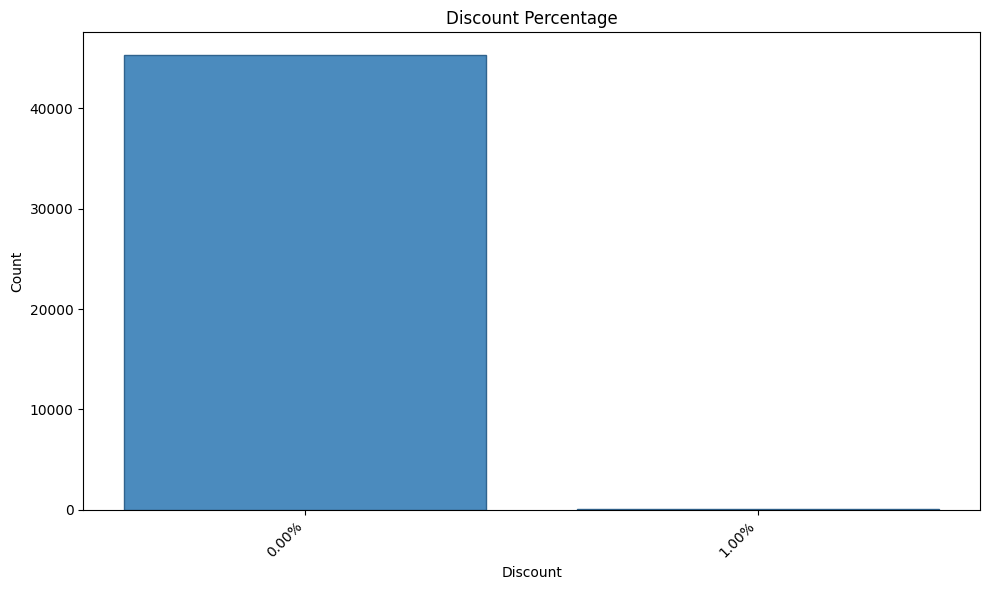

In [38]:
plot_bar_graph(invoice_df['discount_'], title="Discount Percentage", x_label="Discount", y_label="Count")

In [39]:
# # Here need to check if there are other balance that is causing certain record to be as False
# # Check and convert columns to string first, then clean and convert to float
# for col in ['sub_total_bcy', 'shipping_charge_bcy']:
#     invoice_df[col] = invoice_df[col].astype(str).str.replace(',', '').str.replace('USD', '').replace('', '0').astype(float)

# # Calculate total_bcy as the sum of components
# invoice_df['total_bcy_calculated'] = (invoice_df['sub_total_bcy'] + 
#                                      invoice_df['shipping_charge_bcy'] )

# # Check if calculated total matches the original total_bcy
# counts = ((invoice_df['total_bcy_calculated'] - invoice_df['discount_amount'].astype(float)) == invoice_df['total_bcy']).value_counts()
# # when checked with discount amount 41 records are false

# print(counts)

In [40]:
# meaning of adjustment_byc


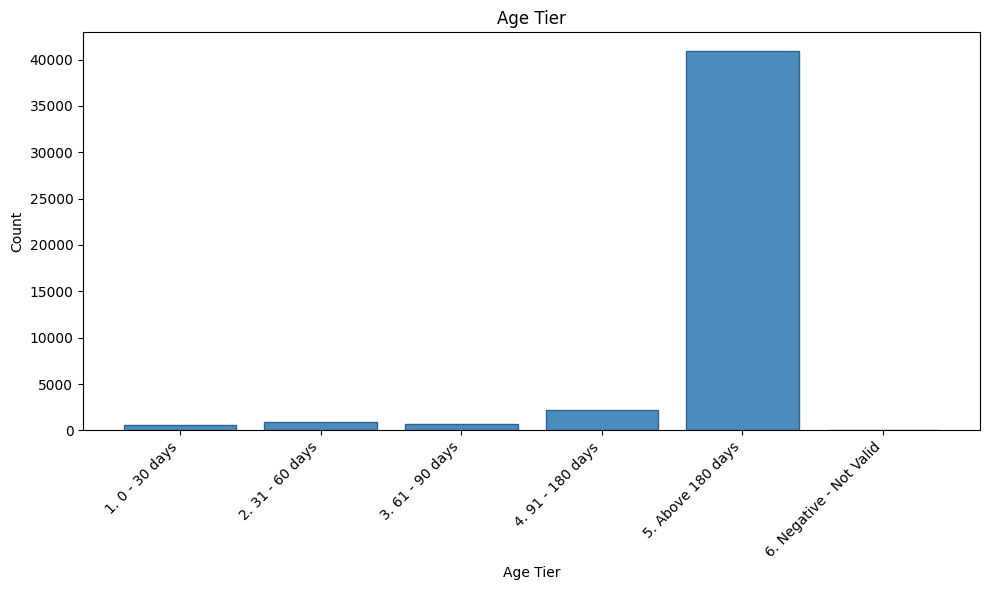

In [41]:
plot_bar_graph(invoice_df['age_tier'], title="Age Tier", x_label="Age Tier", y_label="Count")

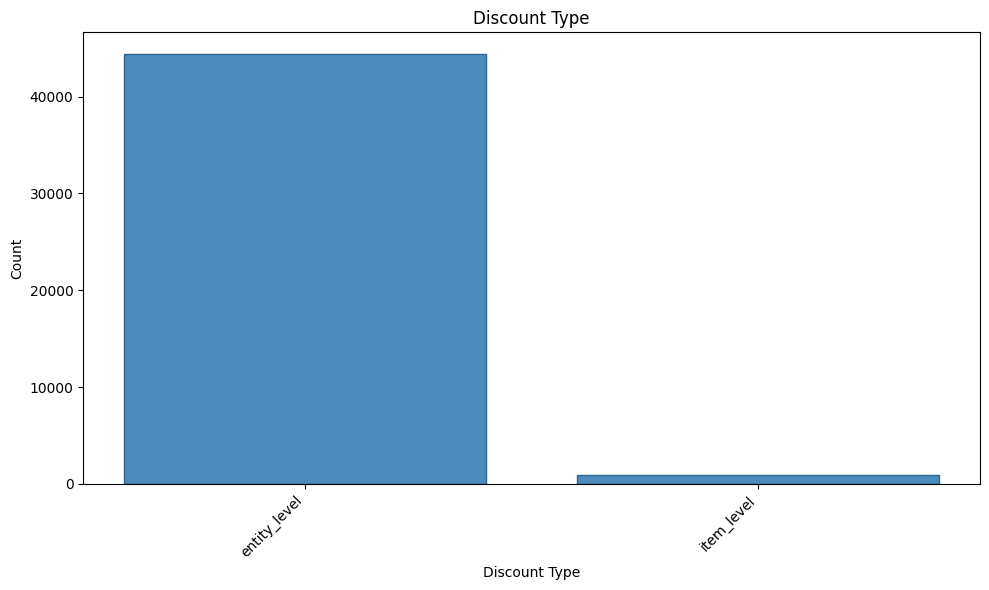

In [42]:
plot_bar_graph(invoice_df['discount_type'], title="Discount Type", x_label="Discount Type", y_label="Count")

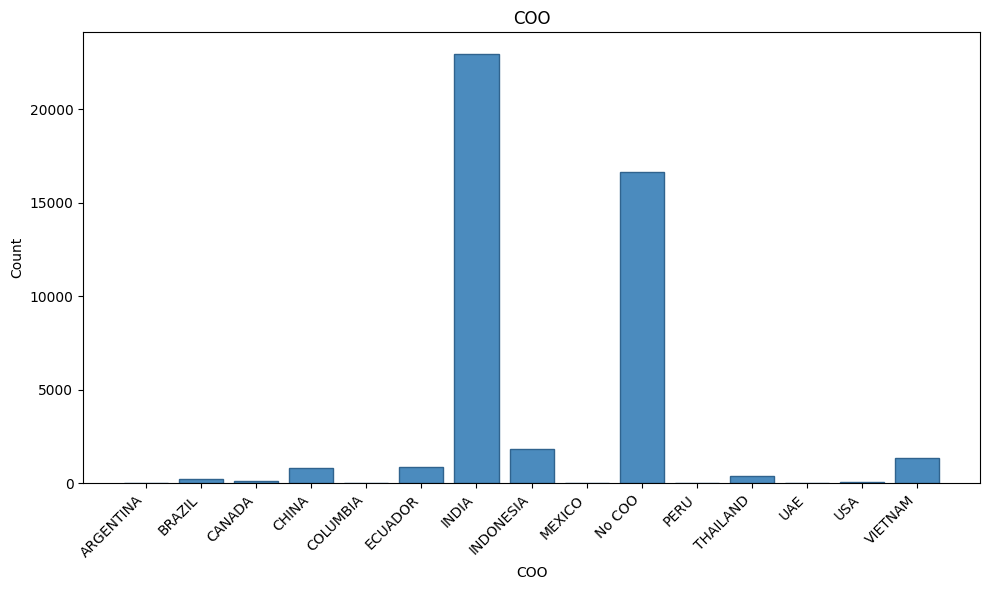

In [43]:
invoice_df['coo'] = invoice_df['coo'].replace('', 'No COO')
plot_bar_graph(invoice_df['coo'], title="COO", x_label="COO", y_label="Count")

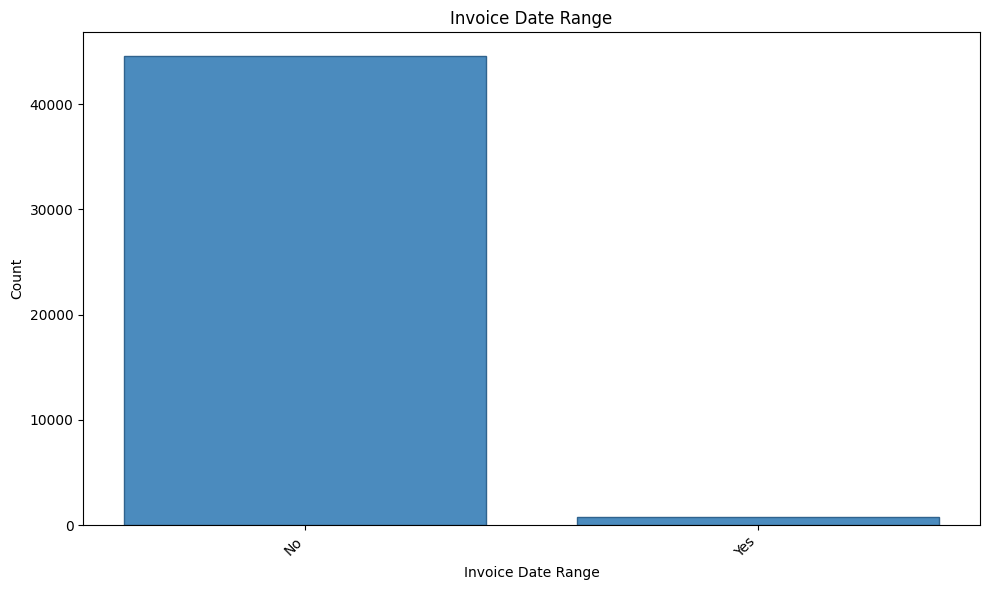

In [44]:
plot_bar_graph(invoice_df['invoice_date_range'], title="Invoice Date Range", x_label="Invoice Date Range", y_label="Count")

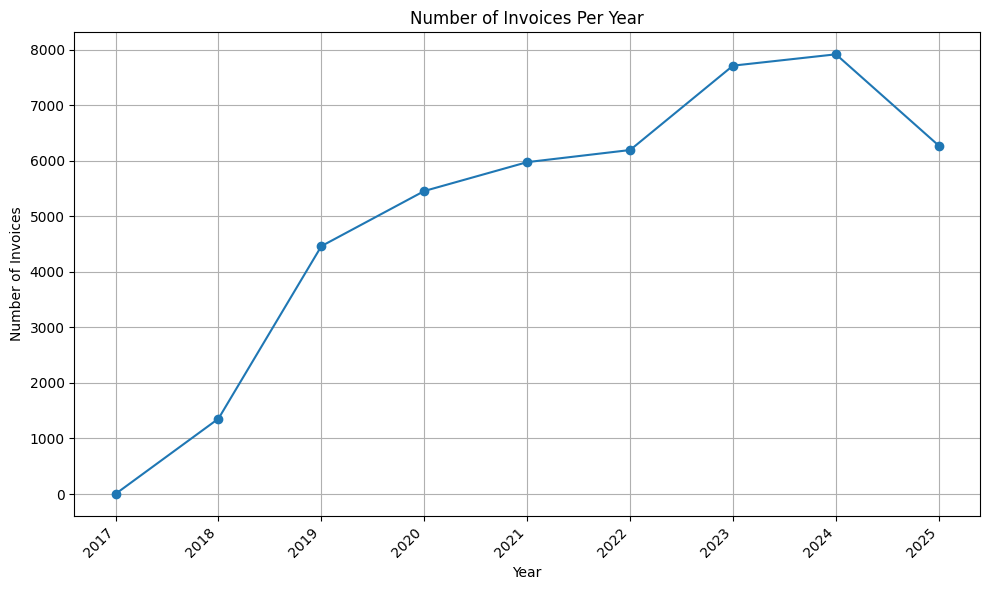

In [45]:
# Assuming df is your DataFrame

# Step 1: Ensure invoice_date is datetime
invoice_df['invoice_date'] = pd.to_datetime(invoice_df['invoice_date'], errors='coerce')

# Step 2: Extract year
invoice_df['invoice_year'] = invoice_df['invoice_date'].dt.year

# Step 3: Count invoices per year
invoices_per_year = invoice_df.groupby('invoice_year')['invoice_number'].count()

# Step 4: Plot using your function
plot_line_graph(
    data_x=invoices_per_year.index,
    data_y=invoices_per_year.values,
    title="Number of Invoices Per Year",
    x_label="Year",
    y_label="Number of Invoices"
)


Average time between invoice date and due date: 25.65 days


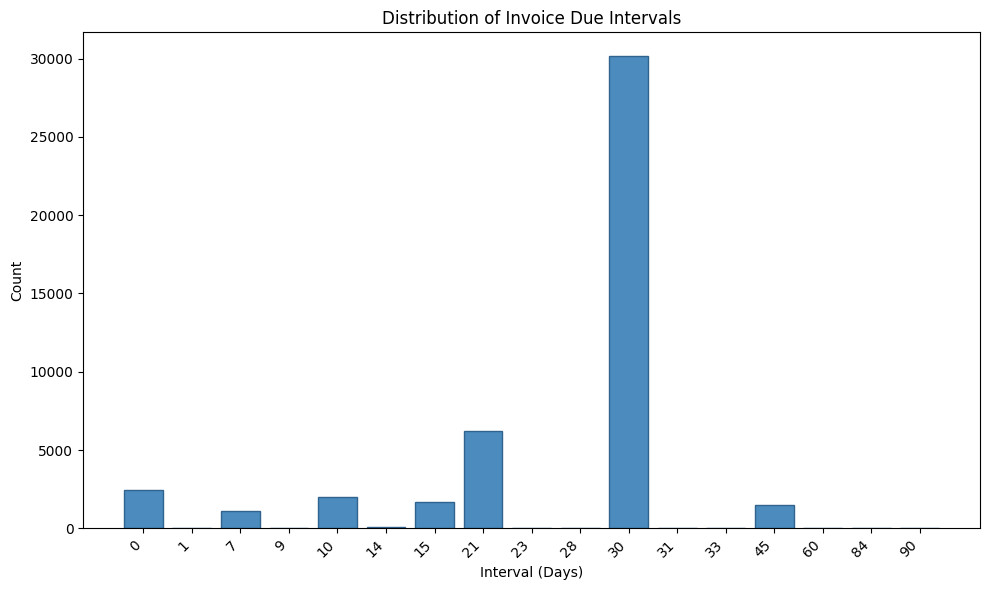

In [46]:
# Step 1: Convert to datetime
invoice_df['invoice_date'] = pd.to_datetime(invoice_df['invoice_date'], errors='coerce')
invoice_df['due_date'] = pd.to_datetime(invoice_df['due_date'], errors='coerce')

# Step 2: Calculate interval in days
invoice_df['due_interval_days'] = (invoice_df['due_date'] - invoice_df['invoice_date']).dt.days

# Step 3: Average interval
avg_interval = invoice_df['due_interval_days'].mean()
print(f"Average time between invoice date and due date: {avg_interval:.2f} days")

# Step 4: Plot distribution
plot_bar_graph(
    invoice_df['due_interval_days'],
    title="Distribution of Invoice Due Intervals",
    x_label="Interval (Days)",
    y_label="Count"
)


In [49]:
# Step 1: Convert to datetime
invoice_df['invoice_date'] = pd.to_datetime(invoice_df['invoice_date'], errors='raise')
invoice_df['pickup_date'] = pd.to_datetime(invoice_df['pickup_date'], errors='raise')

# Step 2: Calculate interval in days
invoice_df['pickup_interval_days'] = (invoice_df['pickup_date'] - invoice_df['invoice_date']).dt.days

# Step 3: Average interval
avg_pickup_interval = invoice_df['pickup_interval_days'].mean()
print(f"Average time between invoice date and pickup date: {avg_pickup_interval:.2f} days")



Average time between invoice date and pickup date: -0.56 days


In [50]:
invoice_df['pickup_date']

0              NaT
1              NaT
2              NaT
3              NaT
4              NaT
           ...    
45339   2025-09-12
45340   2025-09-11
45341   2025-09-16
45342   2025-09-19
45343   2025-09-11
Name: pickup_date, Length: 45344, dtype: datetime64[ns]